# Imports

In [1]:
# Automatically reloads modules before each cell execution, so code changes in library are always propogated.
#reload or load? _ext
%load_ext autoreload
%autoreload 2

%load_ext snakeviz

import networkx as nx
from networkx import MultiDiGraph
import osmnx as ox
import numpy as np
import pandas as pd
from difflib import SequenceMatcher
import concurrent.futures
import copy
import re
from tqdm.notebook import tqdm

from PreProcessing import graph_preprocessing
from NetworkOptimisation import graph_optimisation, heuristic

import graph_util as graph_util
import investigation
import plotting
import constants

ox.settings.useful_tags_way = [
    "bridge", "tunnel", "oneway", "lanes", "highway",
     "width", "name", "name:en", "bicycle", "cycleway", "tunnel"]

LOCATION = "Gozo, Malta"
#LOCATION = "Malta (island)"
safe_location = re.sub(r"[()\[\]{}]", "", LOCATION)
safe_location = re.sub(r"[^0-9A-Za-z_-]+", "_", safe_location)
safe_location = re.sub(r"_+", "_", safe_location).strip("_")

GRAPH_PATH = f"../Data/{safe_location}_master_graph.graphml"
SEED = 72
K_SAMPLE = 100 #NOTE TODO 100 preserves rank but for accurate values use 400; k=50 is the lowest acceptable 
N_ITERATIONS = 20 

# Generate and save master graph

Loading OSM networks for Gozo, Malta...
creating master graph network...


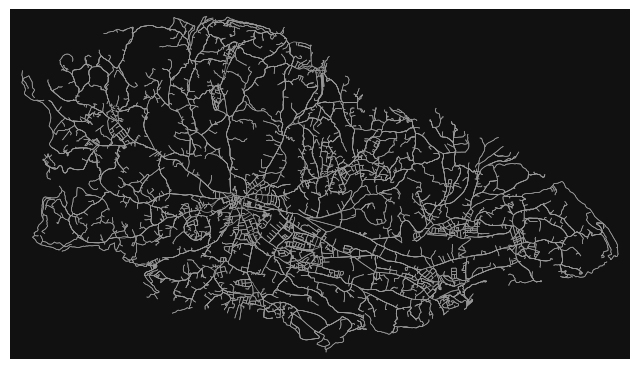

Adding elevation data.....
Imputing missing elevation values
Iteration 1: imputed 29 nodes
Iteration 2: imputed 5 nodes
Iteration 3: imputed 2 nodes
Iteration 4: imputed 0 nodes
Reallocatability summary: [('total', 12395), ('no_car_allowed', 7352), ('reallocatable', 3368), ('no_bike_allowed', 1675)]
Number of localities: 15


In [2]:
#NOTE the length attribute is given in meters
#You project not to fix lengths, but to make sure your geometry math (like areas or spatial intersections) makes sense in linear units.
#Simplify is used to significantly reduce the number of nodes, removing dead ends and combining nodes with no intersections
G_master = graph_preprocessing.load_network(LOCATION)
ox.plot_graph(G_master, node_size=0, edge_linewidth=0.5)
G_master, gdf_regions_proj, gdf_local_proj = graph_preprocessing.clean_graph(G_master, LOCATION)

In [3]:
from PreProcessing import enrich_attributes

G_drive = graph_util.make_drive_subgraph(G_master)
enrich_attributes.tag_reallocatable_edges(G_drive)

Counter({'total': 5043, 'reallocatable': 3368, 'no_bike_allowed': 1675})

In [4]:
edges = list(G_master.edges(keys=True, data=True))
u, v, k, data = edges[0]
print(u, v, k)
print(data)

197798 1497329566 0
{'osmid': [139266489, 1182920597], 'oneway': True, 'highway': 'primary', 'name': 'Triq l-Imġarr', 'name:en': 'Mġarr Road', 'reversed': False, 'length': np.float64(8891328.457949603), 'geometry': <LINESTRING (435887.052 3986835.462, 435907.715 3986827.003, 435926.098 3986...>, 'car_allowed': True, 'bike_allowed': False, 'grade': -0.03809596791827777, 'grade_abs': 0.03809596791827777, 'car_lanes': 1, 'bike_lanes': 0, 'infra_type': 'car', 'safety': <SafetyClass.DANGEROUS: 'dangerous'>, 'risk_factor': 4.0, 'reallocatable': False, 'region': 'Reġjun Għawdex', 'locality': 'Għajnsielem'}


In [5]:
graph_util.summarise_road_type_stats(G_master)

Highway type counts:
residential: 5505
track: 1834
service: 1787
tertiary: 1296
primary: 926
secondary: 669
non_motorised: 378
-------
bikeway classification type counts:
None: 11909
yes: 482
permissive: 4
------
cycleway type counts:
None: 12351
no: 44
------
tunnel counts:
None: 12372
yes: 17
building_passage: 6


In [6]:
ox.io.save_graphml(G_master, filepath=GRAPH_PATH)

gdf_local_proj.to_pickle(f"../Data/{safe_location}_gdf_local_proj.pkl")
gdf_regions_proj.to_pickle(f"../Data/{safe_location}_gdf_regions_proj.pkl")

# Load mastergraph

In [7]:
G_master = ox.io.load_graphml(
    filepath=GRAPH_PATH,
    edge_dtypes={
        "car_lanes": int,
        "bike_lanes": int,
        "car_allowed": ox.io._convert_bool_string,
        "bike_allowed": ox.io._convert_bool_string,
        "reallocatable": ox.io._convert_bool_string,
        "grade": float,
        "grade_abs": float,
        "risk_factor": float,
    },
    node_dtypes={
        "elevation": float
    })

gdf_local_proj = pd.read_pickle(f"../Data/{safe_location}_gdf_local_proj.pkl")
gdf_regions_proj = pd.read_pickle(f"../Data/{safe_location}_gdf_regions_proj.pkl")

# Network Inspection

## Road type classification

In [8]:
graph_util.summarise_road_type_stats(G_master)

Highway type counts:
residential: 5505
track: 1834
service: 1787
tertiary: 1296
primary: 926
secondary: 669
non_motorised: 378
-------
bikeway classification type counts:
None: 11909
yes: 482
permissive: 4
------
cycleway type counts:
None: 12351
no: 44
------
tunnel counts:
None: 12372
yes: 17
building_passage: 6


In [9]:
print("Nodes:", G_master.number_of_nodes())
print("Edges (total, counts parallel edges separately):", G_master.number_of_edges())
print(G_master.graph)

Nodes: 4982
Edges (total, counts parallel edges separately): 12395
{'created_date': '2025-11-30 18:33:34', 'created_with': 'OSMnx 2.0.5', 'crs': 'EPSG:32633', 'simplified': True}


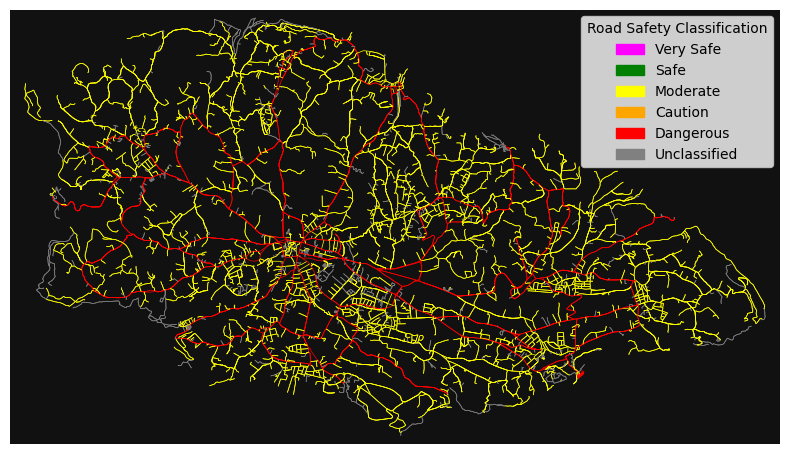

In [10]:
plotting.plot_road_classification(G_master)

## Parallel Edges

Directed node pairs: 12291
Pairs with parallel edges (>1): 104
Total extra edges beyond single-edge pairs: 104
Max parallel edges on a single pair: 2

Top pairs by parallel edges:
  (12531417331 -> 324401000): 2
  (255138121 -> 255138122): 2
  (2667095061 -> 599068672): 2
  (262015684 -> 262015685): 2
  (153211317 -> 2666647165): 2
  (2666647165 -> 153211317): 2
  (2511785737 -> 255442806): 2
  (9088984481 -> 9088984481): 2
  (261695745 -> 261695746): 2
  (261695746 -> 261695745): 2

Distribution (parallel_count -> number of (u,v) pairs):
  1: 12187
  2: 104
Parallel edge attribute comparison:
  same_highway_and_cycleway     : 174
  different_highway_only        : 30
  different_cycleway_only       : 4


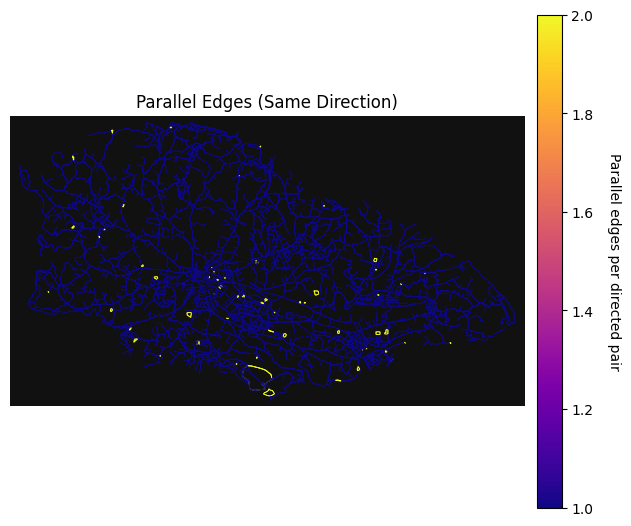

-----


In [11]:
investigation.analyze_parallel_edges(G_master)
investigation.compare_parallel_edges(G_master)
investigation.plot_parallel_edges(G_master)
print("-----")

## Reallocatability

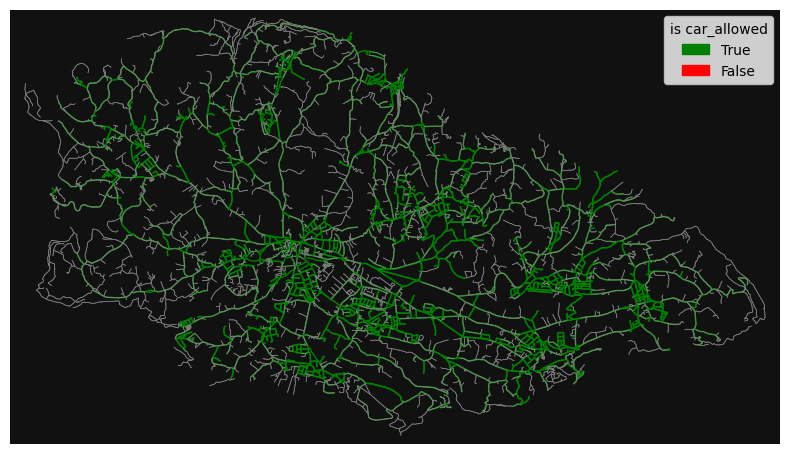

In [12]:
plotting.plot_bool_atr(G_master, "car_allowed")

In [13]:
bridges = set(nx.bridges(G_master.to_undirected()))
print(len(bridges), "actual num might be double actually")

1786 actual num might be double actually


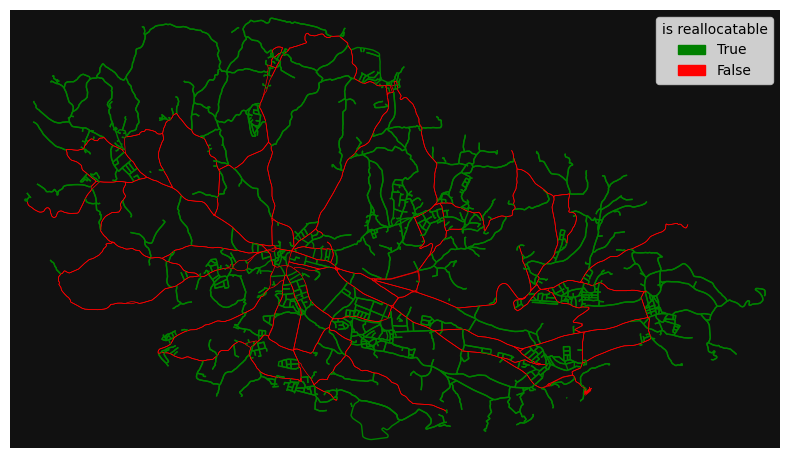

In [14]:
G_drive = graph_util.make_drive_subgraph(G_master)
plotting.plot_bool_atr(G_drive, "reallocatable")

In [15]:
reallocatable_false = 0
reallocatable_true =0
for u, v, k, d in G_drive.edges(keys=True, data=True):
    if d.get("reallocatable"):
        reallocatable_true += 1
    else:
        reallocatable_false += 1

print(f"realloacable true: {reallocatable_true},", f"realloaclable false {reallocatable_false},", f"{reallocatable_true/(reallocatable_true+reallocatable_false)*100}% are reallocable")

realloacable true: 3368, realloaclable false 1675, 66.78564346619076% are reallocable


## Topology

Fetched elevations for 4982 / 4982 nodes


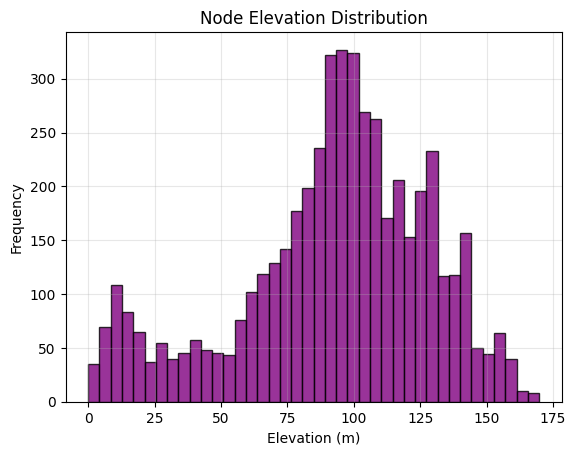

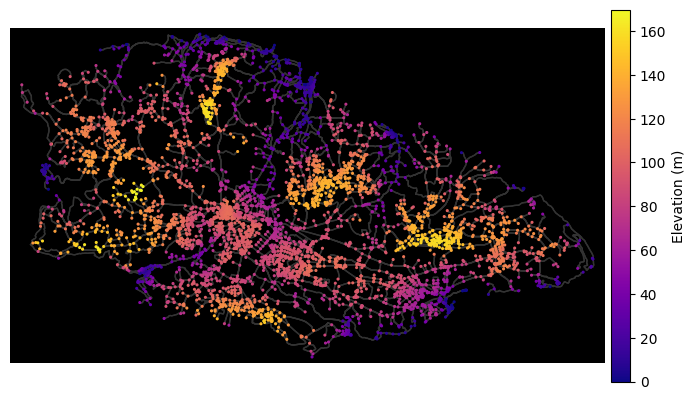

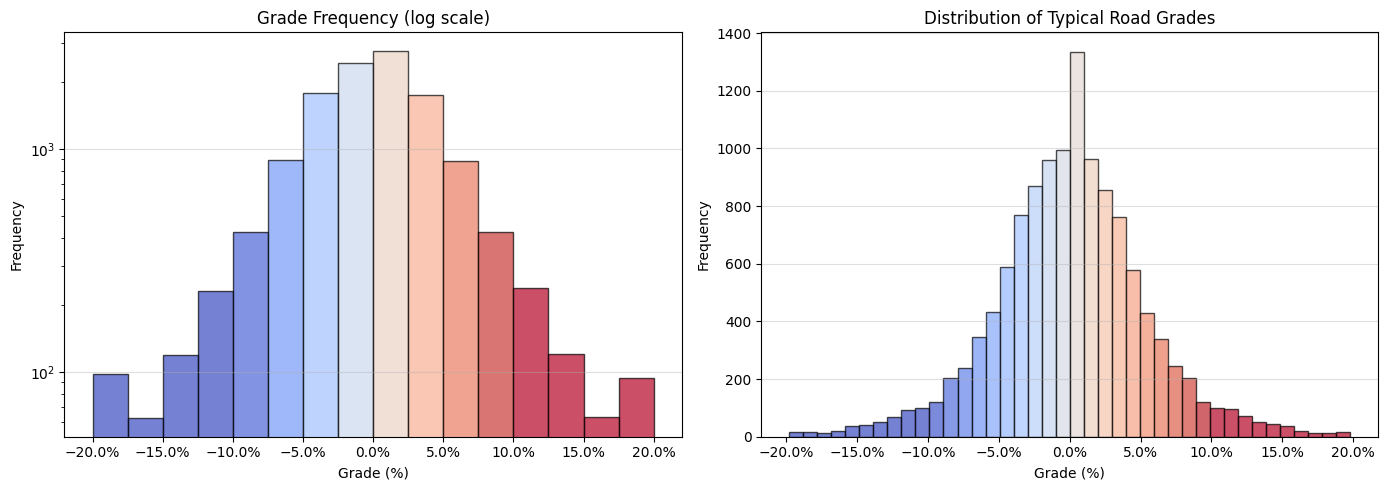

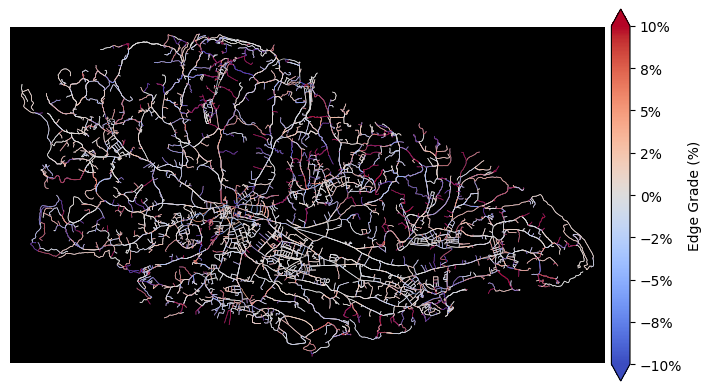

In [16]:
plotting.plot_elevation(G_master)
plotting.plot_grades(G_master)

## Network statistics

In [17]:
"""# what sized area does our network cover in square meters?
bike_nodes_proj = ox.convert.graph_to_gdfs(my_graph.G_master, edges=False) #Get only nodes
graph_area_m = bike_nodes_proj.union_all().convex_hull.area
# show some basic stats about the network
stats = ox.stats.basic_stats(my_graph.G_master, area=graph_area_m, clean_int_tol=15)"""

'# what sized area does our network cover in square meters?\nbike_nodes_proj = ox.convert.graph_to_gdfs(my_graph.G_master, edges=False) #Get only nodes\ngraph_area_m = bike_nodes_proj.union_all().convex_hull.area\n# show some basic stats about the network\nstats = ox.stats.basic_stats(my_graph.G_master, area=graph_area_m, clean_int_tol=15)'

In [18]:
edge_keys = set()
for u,v,data in G_master.edges(data=True):
    edge_keys.update(data.keys())
print(edge_keys)

{'car_lanes', 'name:en', 'safety', 'bike_allowed', 'cycleway', 'name', 'width', 'car_allowed', 'bicycle', 'grade', 'infra_type', 'reallocatable', 'oneway', 'highway', 'bike_lanes', 'osmid', 'length', 'tunnel', 'grade_abs', 'risk_factor', 'bridge', 'parallel_count', 'region', 'reversed', 'locality', 'geometry'}


# Generating city level subgraphs

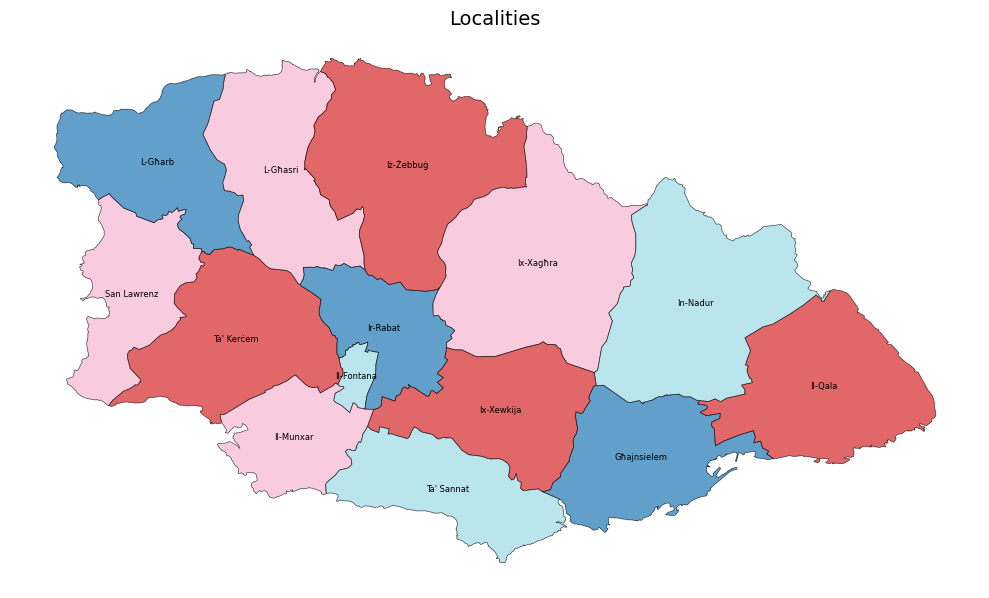

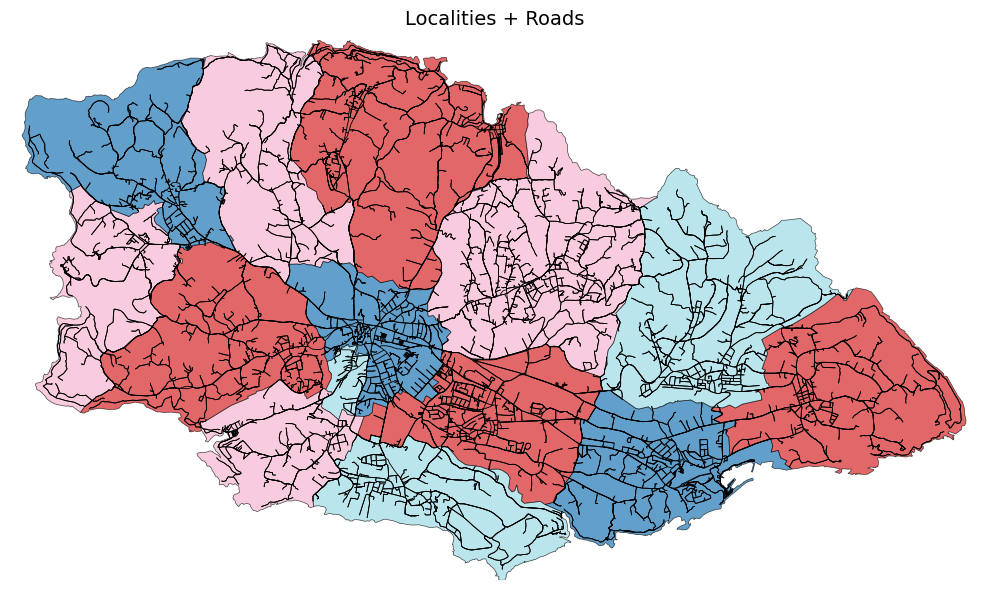

----


In [19]:
#plotting.plot_gdf_and_overlay(gdf_regions_proj, "Regions", annotate=True)
plotting.plot_gdf_and_overlay(gdf_local_proj, "Localities", annotate=True)
plotting.plot_gdf_and_overlay(gdf_local_proj, "Localities + Roads", G=G_master, annotate=False)
print("----")

In [20]:
subgraphs = {}
total_nodes = 0
total_edges = 0
for idx, row in gdf_local_proj.iterrows():
    name = row["name"]

    G_sub = graph_util.make_locality_subgraph(G_master, name)
    subgraphs[name] = G_sub
    total_nodes += len(G_sub.nodes)
    total_edges += len(G_sub.edges)
    print(f"✅ Created subgraph for {name}: {len(G_sub.nodes)} nodes, {len(G_sub.edges)} edges")

print(f"total_nodes{total_nodes}, total_edges{total_edges}")

✅ Created subgraph for Għajnsielem: 446 nodes, 1088 edges
✅ Created subgraph for Il-Fontana: 78 nodes, 158 edges
✅ Created subgraph for Ta' Kerċem: 410 nodes, 922 edges
✅ Created subgraph for San Lawrenz: 184 nodes, 391 edges
✅ Created subgraph for L-Għarb: 263 nodes, 597 edges
✅ Created subgraph for L-Għasri: 246 nodes, 533 edges
✅ Created subgraph for Ir-Rabat: 605 nodes, 1390 edges
✅ Created subgraph for Iż-Żebbuġ: 540 nodes, 1266 edges
✅ Created subgraph for Ix-Xagħra: 635 nodes, 1542 edges
✅ Created subgraph for Il-Qala: 355 nodes, 832 edges
✅ Created subgraph for In-Nadur: 396 nodes, 1022 edges
✅ Created subgraph for Ix-Xewkija: 590 nodes, 1490 edges
✅ Created subgraph for Il-Munxar: 212 nodes, 495 edges
✅ Created subgraph for Ta' Sannat: 274 nodes, 669 edges
total_nodes5234, total_edges12395


# Topological Metrics

Evaluating how good a network is

In [21]:
# Directness - measures how efficiently users can travel between two point

# Centrality
#network_evaluation(graph_util.make_protected_subgraph(G_master))
## Degree - number of connections per node

# Optimisation Approaches 

## Heuristic Approaches

Centrality - betweeness and closeness

the relative ordering of nodes (or edges) is virtually identical.

Relative error → Measures absolute value difference (how far are the actual numbers).

Correlation (or Spearman’s ρ) → Measures rank consistency (how well the ordering is preserved

4982


k samples:   0%|          | 0/5 [00:00<?, ?k/s]

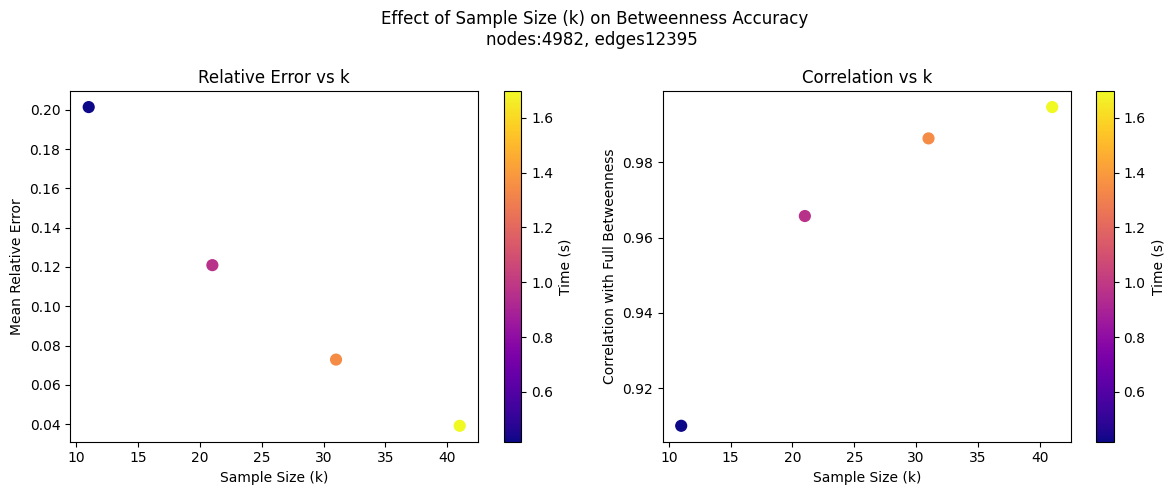

In [22]:
import time
from matplotlib import pyplot as plt
from networkx import DiGraph

def investigate_k_diff(G:DiGraph, max_k = None, seed=42, step=50):
    if max_k == None:
        max_k = len(G.nodes)

    edges = len(G.edges)
    #TODO this really should be k=NONE
    true_bc = nx.betweenness_centrality(G, weight="length", normalized=True, k=max_k, seed=seed)

    results = []
    iterable = range(1, max_k, step)
    for k in tqdm(iterable, desc="k samples", unit="k"):
        t0 = time.perf_counter()
        approx_bc = nx.betweenness_centrality(G, weight="length", normalized=True, k=k, seed=seed)
        elapsed = time.perf_counter() - t0

        # convert to arrays for shared nodes
        true_vals = np.array([true_bc[n] for n in G.nodes])
        approx_vals = np.array([approx_bc[n] for n in G.nodes])

        # relative mean absolute error
        rel_err = np.mean(np.abs(approx_vals - true_vals) / (true_vals + 1e-9))
        # correlation
        corr = np.corrcoef(true_vals, approx_vals)[0, 1]

        results.append((k, rel_err, corr, elapsed))
        #print(f"k={k:>5} | rel_err={rel_err:.3f} | corr={corr:.3f} | time={elapsed:.2f}s")

    ks, rel_errs, corrs, times = zip(*results)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    scatter1 = ax[0].scatter(ks, rel_errs, c=times, cmap="plasma", s=60)
    ax[0].set_title("Relative Error vs k")
    ax[0].set_xlabel("Sample Size (k)")
    ax[0].set_ylabel("Mean Relative Error")
    cbar = plt.colorbar(scatter1, ax=ax[0]); cbar.set_label("Time (s)")

    scatter2 = ax[1].scatter(ks, corrs, c=times, cmap="plasma", s=60)
    ax[1].set_title("Correlation vs k")
    ax[1].set_xlabel("Sample Size (k)")
    ax[1].set_ylabel("Correlation with Full Betweenness")
    cbar2 = plt.colorbar(scatter2, ax=ax[1]); cbar2.set_label("Time (s)")

    plt.suptitle(f"Effect of Sample Size (k) on Betweenness Accuracy\nnodes:{len(G.nodes)}, edges{edges} ")
    plt.tight_layout()
    plt.show()

print(len(G_master.nodes))
investigate_k_diff(G_master,max_k=50, seed=12, step=10)

In [24]:
#%snakeviz -t
#TODO getting new very safe edges even tho nothing got allocated?
heuristics = {
    #"L2S": heuristic.heuristic_L2S,
    "edge_betweenness": heuristic.heuristic_edge_betweenness_centrality,
   # "edge_betweenness2": heuristic.heuristic_edge_betweenness_centrality,
}

chosen_localities = {"Birkirkara", "Il-Birgu"}  # use set for fast membership
subgraphs = {name: G for name, G in subgraphs.items() if name in chosen_localities}

#NOTE majority of computation time is spent on evaluation 
all_results = []
for name, func in heuristics.items():
    print(f"Running {name} heuristic")
    df = graph_optimisation.run_global(
        G_master,
        heuristic_func=func,
        n_iterations=100,
        max_workers=7,
        EVALUATION_MOD=1,
        k_sample = 25, 
        parallel=False,
    )
    df["heuristic"] = name
    all_results.append(df)

optimised_graph_results_df = pd.concat(all_results, ignore_index=True)
optimised_graph_results_df.sort_values(by=["heuristic", "locality", "iteration"])
optimised_graph_results_df.head()

Running edge_betweenness heuristic


Processing localities:   0%|          | 0/1 [00:00<?, ?loc/s]

🏙️ Starting MASTER in process


Iterations (MASTER):   0%|          | 0/100 [00:00<?, ?iter/s]

(160132018, 9784970788, 0)
(9784970788, 160135213, 0)
(330038151, 1501758223, 0)
(160135213, 158597238, 0)
(1501758223, 262021996, 0)
(153215456, 153215453, 0)
(262021996, 262022052, 0)
(262022052, 262022053, 0)
(158597238, 158606961, 0)
(11989967229, 160173308, 0)
(160173308, 171177998, 0)
(306285017, 160132018, 0)
(158606961, 158607886, 0)
(158607886, 150609422, 0)
(171177998, 160171208, 0)
(153216115, 160293521, 0)
(255442801, 2666647106, 0)
(160171208, 1546011180, 0)
(2666647106, 8994418800, 0)
(8994418800, 4085343704, 0)
(4085343704, 2316785919, 0)
(150609422, 5933468263, 0)
(5933468263, 150609420, 0)
(2316785919, 153206941, 0)
(1546011180, 160166055, 0)
(160293521, 153215620, 0)
(153215620, 291109112, 0)
(150609420, 5933468262, 0)
(5933468262, 1542538288, 0)
(262022053, 330038093, 0)
(153206941, 158589605, 0)
(153215453, 2666647068, 0)
(160166055, 160157238, 0)
(1542538288, 150609418, 0)
(2666647068, 153206954, 0)
(291109112, 156217381, 0)
(150609418, 1534377018, 0)
(153206954, 3

,num_components,lcc_length,mean_edge_betweenness,mean_node_betweenness,mean_node_closeness,mean_degree,mean_directness,locality,iteration,diff_log,heuristic
0,0,0.000000e+00,0.000000,0.000000,0.0,0.000000,0.0,MASTER,0,[],edge_betweenness
1,1,7.882883e+06,0.500000,0.000000,1.0,2.000000,1.0,MASTER,1,"[{'type': 'realloc', 'edge': (160132018, 97849...",edge_betweenness
2,1,2.586877e+07,0.333333,0.333333,1.0,2.666667,1.0,MASTER,2,"[{'type': 'realloc', 'edge': (9784970788, 1601...",edge_betweenness
3,2,2.586877e+07,0.333333,0.333333,1.0,2.666667,1.0,MASTER,3,"[{'type': 'realloc', 'edge': (330038151, 15017...",edge_betweenness
4,2,4.416523e+07,0.277778,0.333333,1.0,3.000000,1.0,MASTER,4,"[{'type': 'realloc', 'edge': (160135213, 15859...",edge_betweenness


In [ ]:
"""%snakeviz -t df=graph_optimisation.run_global(G_master, subgraphs, heuristic_func=heuristic.heuristic_edge_betweenness_centrality, n_iterations=5, max_workers=7, EVALUATION_MOD=5, k_sample = 50,  parallel=False)"""

'%snakeviz -t df=graph_optimisation.run_global(G_master, subgraphs, heuristic_func=heuristic.heuristic_edge_betweenness_centrality, n_iterations=5, max_workers=7, EVALUATION_MOD=5, k_sample = 50,  parallel=False)'

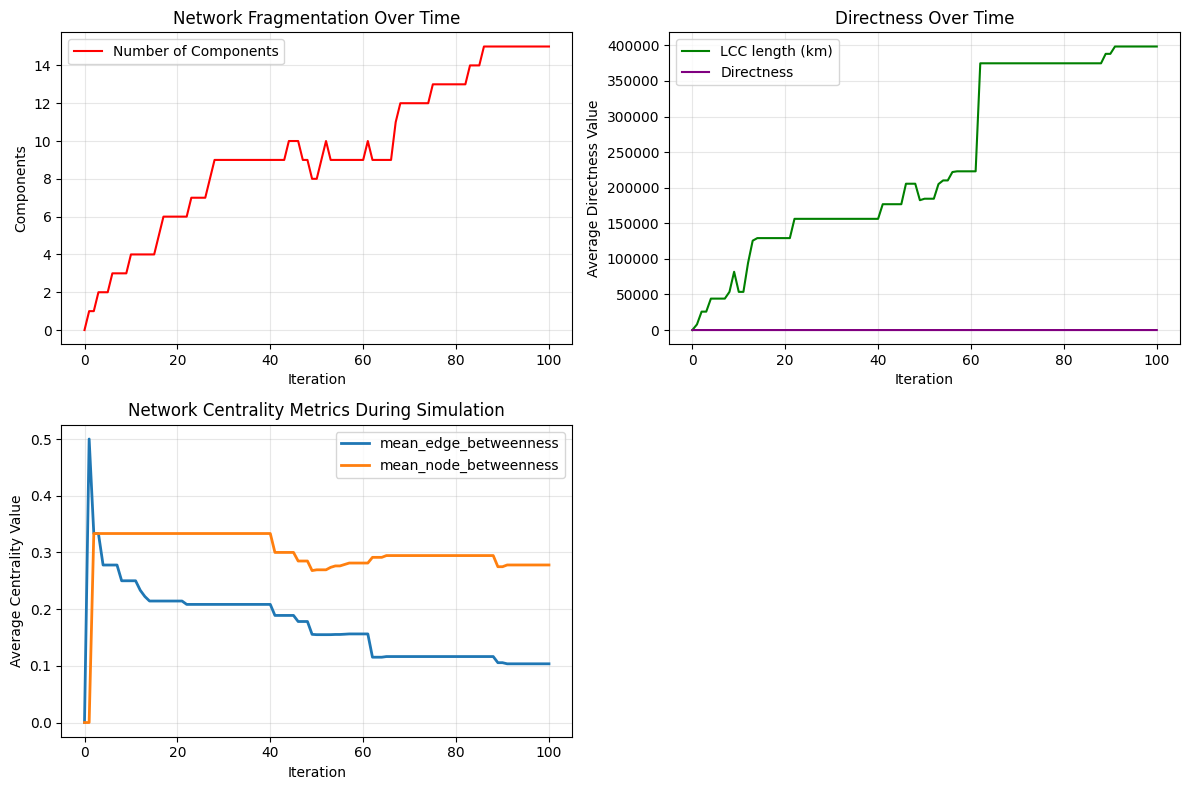

In [25]:
chosen_heuristic = 'edge_betweenness'
chosen_locality = "MASTER"

optimised_locality_heuristic_df = optimised_graph_results_df[
    (optimised_graph_results_df['heuristic'] == chosen_heuristic) &
    (optimised_graph_results_df['locality'] == chosen_locality)
]
plotting.plot_evaluation(optimised_locality_heuristic_df)

In [26]:
#G_locality= graph_util.make_locality_subgraph(G_master,chosen_locality)
#plotting.plot_directionality(G_master)

In [27]:
edges = list(G_master.edges(keys=True, data=True))
u, v, k, data = edges[0]
print(u, v, k)
display(data)

197798 1497329566 0


{'osmid': [139266489, 1182920597],
 'oneway': True,
 'highway': 'primary',
 'name': 'Triq l-Imġarr',
 'name:en': 'Mġarr Road',
 'reversed': False,
 'length': 8891328.457949603,
 'geometry': <LINESTRING (435887.052 3986835.462, 435907.715 3986827.003, 435926.098 3986...>,
 'car_allowed': True,
 'bike_allowed': False,
 'grade': -0.03809596791827777,
 'grade_abs': 0.03809596791827777,
 'car_lanes': 1,
 'bike_lanes': 0,
 'infra_type': 'car',
 'safety': 'dangerous',
 'risk_factor': 4.0,
 'reallocatable': False,
 'region': 'Reġjun Għawdex',
 'locality': 'Għajnsielem',
 'parallel_count': 1}

In [28]:
missing = [(u, v, k) for u, v, k, d in G_master.edges(keys=True, data=True) if d.get("width") is None]
print("Edges without width:", len(missing), "/", G_master.number_of_edges(), f"({100*len(missing)/G_master.number_of_edges():.2f}%)")
# show up to 10 examples
print("Examples:", missing[:10])

Edges without width: 12323 / 12395 (99.42%)
Examples: [(197798, 1497329566, 0), (197798, 158611509, 0), (197798, 13169274834, 0), (1497329566, 1494342639, 0), (1497329566, 158591473, 0), (158611509, 60794838, 0), (158611509, 197798, 0), (158611509, 158611353, 0), (158611509, 3525042262, 0), (13169274834, 197798, 0)]


In [ ]:
diff_log_series = optimised_locality_heuristic_df["diff_log"]
diff_log = diff_log_series.explode().dropna().tolist()

plotting.plot_snapshots(graph_util.make_bikeable_subgraph(G_master), diff_log, num_snapshots=4, show_classification=False)
plotting.plot_snapshots(G_master, diff_log, num_snapshots=4, show_classification=True)

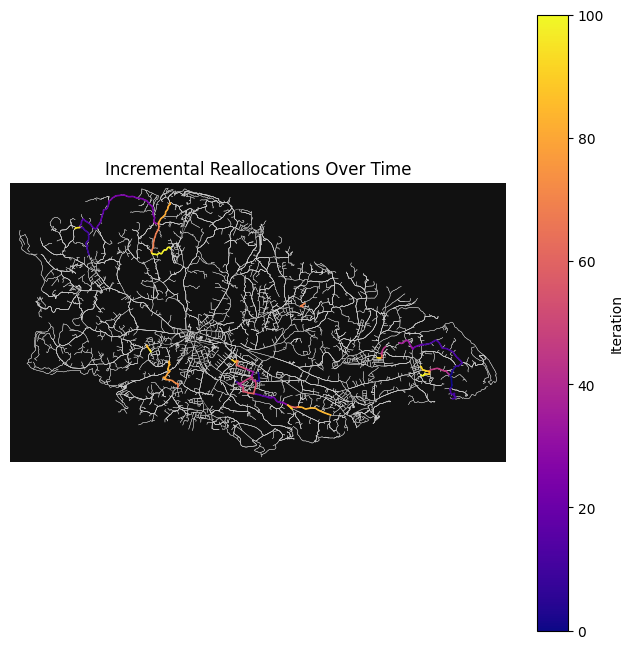

In [ ]:
plotting.plot_network_evolution2(G_master, diff_log)